## 0) 설치/임포트

In [1]:
import os
import gc
import re
import io
import json
import math
import random
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

import sentencepiece as spm

## 1) 경로/시드/기본 설정

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

HOME = os.getenv("HOME")
BASE_DIR = os.path.join(HOME, "work", "mini_bert_project")
DATA_DIR = os.path.join(BASE_DIR, "data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
ART_DIR = os.path.join(BASE_DIR, "artifacts")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(ART_DIR, exist_ok=True)

# 원본 코퍼스 경로
corpus_file = os.path.join(HOME, "work", "bert_pretrain", "data", "kowiki.txt")

# sentencepiece 모델 경로
spm_prefix = os.path.join(MODEL_DIR, "ko_8000")
spm_model_path = f"{spm_prefix}.model"
spm_vocab_path = f"{spm_prefix}.vocab"

# 전처리 산출물 경로
jsonl_path = os.path.join(DATA_DIR, "mini_bert_pretrain.jsonl")
meta_json_path = os.path.join(DATA_DIR, "mini_bert_pretrain_meta.json")

input_ids_mmap_path = os.path.join(DATA_DIR, "input_ids.memmap")
segment_ids_mmap_path = os.path.join(DATA_DIR, "segment_ids.memmap")
mlm_labels_mmap_path = os.path.join(DATA_DIR, "mlm_labels.memmap")
nsp_labels_mmap_path = os.path.join(DATA_DIR, "nsp_labels.memmap")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2) SentencePiece 학습 또는 로드

In [3]:
VOCAB_SIZE = 8000

if not os.path.exists(spm_model_path):
    spm.SentencePieceTrainer.train(
        f"--input={corpus_file} "
        f"--model_prefix={spm_prefix} "
        f"--vocab_size={VOCAB_SIZE} "
        "--model_type=bpe "
        "--max_sentence_length=999999 "
        "--character_coverage=0.9995 "
        "--pad_id=0 --pad_piece=[PAD] "
        "--unk_id=1 --unk_piece=[UNK] "
        "--bos_id=2 --bos_piece=[BOS] "
        "--eos_id=3 --eos_piece=[EOS] "
        "--user_defined_symbols=[SEP],[CLS],[MASK]"
    )
    print("sentencepiece model trained.")
else:
    print("existing sentencepiece model found.")

sentencepiece model trained.


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=/home/jovyan/work/bert_pretrain/data/kowiki.txt --model_prefix=/home/jovyan/work/mini_bert_project/models/ko_8000 --vocab_size=8000 --model_type=bpe --max_sentence_length=999999 --character_coverage=0.9995 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /home/jovyan/work/bert_pretrain/data/kowiki.txt
  input_format: 
  model_prefix: /home/jovyan/work/mini_bert_project/models/ko_8000
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 999999
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_num

In [4]:
vocab = spm.SentencePieceProcessor()
vocab.load(spm_model_path)

PAD_ID  = vocab.pad_id()                      # 0
UNK_ID  = vocab.unk_id()                      # 1
BOS_ID  = vocab.bos_id()                      # 2
EOS_ID  = vocab.eos_id()                      # 3
SEP_ID  = vocab.piece_to_id("[SEP]")          # 4
CLS_ID  = vocab.piece_to_id("[CLS]")          # 5
MASK_ID = vocab.piece_to_id("[MASK]")         # 6

print("vocab size:", vocab.get_piece_size())
print("PAD, UNK, BOS, EOS, SEP, CLS, MASK =", PAD_ID, UNK_ID, BOS_ID, EOS_ID, SEP_ID, CLS_ID, MASK_ID)

vocab size: 8000
PAD, UNK, BOS, EOS, SEP, CLS, MASK = 0 1 2 3 4 5 6


## 3) 문장 정리 함수

In [5]:
def clean_text(text: str) -> str:
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

def valid_line(text: str) -> bool:
    text = clean_text(text)
    if len(text) < 2:
        return False
    # 너무 짧거나 의미 없는 줄 제거
    if text.startswith("<") and text.endswith(">"):
        return False
    return True

def load_valid_sentences(path, max_lines=None):
    sentences = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if max_lines is not None and i >= max_lines:
                break
            line = clean_text(line)
            if valid_line(line):
                sentences.append(line)
    return sentences

## 4) MLM / NSP 샘플 생성 함수
15% 마스킹, 그중 80%는 [MASK], 10% 랜덤, 10% 원형 유지. 그리고 NSP는 50% 정답/오답으로 만든다.

In [6]:
def truncate_seq_pair(tokens_a, tokens_b, max_num_tokens):
    while len(tokens_a) + len(tokens_b) > max_num_tokens:
        if len(tokens_a) > len(tokens_b):
            tokens_a.pop()
        else:
            tokens_b.pop()

def create_masked_lm_predictions(token_ids, mask_id, vocab_size, cls_id, sep_id, pad_id,
                                 masked_lm_prob=0.15, max_predictions_per_seq=None):
    """
    BERT MLM 규칙:
    - 전체 토큰의 15% 선택
    - 80%: [MASK]
    - 10%: random token
    - 10%: original token 유지
    labels는 예측해야 하는 위치만 원래 토큰 id, 나머지는 pad_id(=0)
    """
    cand_indices = []
    for i, tid in enumerate(token_ids):
        if tid in [cls_id, sep_id, pad_id]:
            continue
        cand_indices.append(i)

    random.shuffle(cand_indices)

    if max_predictions_per_seq is None:
        num_to_predict = max(1, int(round(len(token_ids) * masked_lm_prob)))
    else:
        num_to_predict = min(max_predictions_per_seq,
                             max(1, int(round(len(token_ids) * masked_lm_prob))))

    output_tokens = list(token_ids)
    labels = [pad_id] * len(token_ids)

    masked_count = 0
    for idx in cand_indices:
        if masked_count >= num_to_predict:
            break

        original_id = token_ids[idx]
        prob = random.random()

        if prob < 0.8:
            output_tokens[idx] = mask_id
        elif prob < 0.9:
            output_tokens[idx] = random.randint(0, vocab_size - 1)
        else:
            output_tokens[idx] = original_id

        labels[idx] = original_id
        masked_count += 1

    return output_tokens, labels

def create_nsp_instance(sent_a, sent_b, vocab, max_seq_len, is_next):
    """
    [CLS] sent_a [SEP] sent_b [SEP]
    segments: 0 0 ... 0 1 1 ... 1
    """
    tokens_a = vocab.encode_as_ids(sent_a)
    tokens_b = vocab.encode_as_ids(sent_b)

    # [CLS], [SEP], [SEP] 3개 자리 확보
    max_num_tokens = max_seq_len - 3
    truncate_seq_pair(tokens_a, tokens_b, max_num_tokens)

    input_ids = [CLS_ID] + tokens_a + [SEP_ID] + tokens_b + [SEP_ID]
    segment_ids = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

    return input_ids, segment_ids, int(is_next)

def pad_to_length(seq, max_len, pad_value=0):
    if len(seq) < max_len:
        seq = seq + [pad_value] * (max_len - len(seq))
    return seq[:max_len]

## 5) memmap + jsonl로 데이터셋 만들기
전체를 리스트로 쌓지 않고, 한 샘플씩 바로 저장한다.

In [7]:
MAX_SEQ_LEN = 128
MAX_SAMPLES = 120_000   # 너무 크게 잡으면 다시 메모리/시간 부담. 12만 정도면 프로젝트용으로 무난.
MAX_LINES_FOR_SENT_POOL = 250_000  # 코퍼스에서 가져올 줄 수 상한

sent_pool = load_valid_sentences(corpus_file, max_lines=MAX_LINES_FOR_SENT_POOL)
print("valid sentences:", len(sent_pool))
print(sent_pool[:3])

valid sentences: 191449
['지미 카터', '제임스 얼 "지미" 카터 주니어(, 1924년 10월 1일 ~ )는 민주당 출신 미국 39번째 대통령 (1977년 ~ 1981년)이다.', '지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다. 조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로 일하였다. 1953년 미국 해군 대위로 예편하였고 이후 땅콩·면화 등을 가꿔 많은 돈을 벌었다. 그의 별명이 "땅콩 농부" (Peanut Farmer)로 알려졌다.']


In [8]:
def build_pretrain_dataset_jsonl_and_memmap(
    sentences,
    vocab,
    max_samples,
    max_seq_len,
    jsonl_path,
    meta_json_path,
    input_ids_mmap_path,
    segment_ids_mmap_path,
    mlm_labels_mmap_path,
    nsp_labels_mmap_path,
):
    vocab_size = vocab.get_piece_size()

    input_ids_mm = np.memmap(input_ids_mmap_path, dtype=np.int32, mode="w+", shape=(max_samples, max_seq_len))
    segment_ids_mm = np.memmap(segment_ids_mmap_path, dtype=np.int8,  mode="w+", shape=(max_samples, max_seq_len))
    mlm_labels_mm = np.memmap(mlm_labels_mmap_path, dtype=np.int32, mode="w+", shape=(max_samples, max_seq_len))
    nsp_labels_mm = np.memmap(nsp_labels_mmap_path, dtype=np.int8,  mode="w+", shape=(max_samples,))

    count = 0

    with open(jsonl_path, "w", encoding="utf-8") as fout:
        for i in tqdm(range(len(sentences) - 1)):
            if count >= max_samples:
                break

            sent_a = sentences[i]

            # 50% true next, 50% random next
            if random.random() < 0.5:
                sent_b = sentences[i + 1]
                is_next = 1
            else:
                rand_idx = random.randint(0, len(sentences) - 1)
                while rand_idx == i + 1:
                    rand_idx = random.randint(0, len(sentences) - 1)
                sent_b = sentences[rand_idx]
                is_next = 0

            input_ids, segment_ids, nsp_label = create_nsp_instance(
                sent_a, sent_b, vocab, max_seq_len, is_next
            )

            masked_input_ids, mlm_labels = create_masked_lm_predictions(
                input_ids,
                mask_id=MASK_ID,
                vocab_size=vocab_size,
                cls_id=CLS_ID,
                sep_id=SEP_ID,
                pad_id=PAD_ID,
                masked_lm_prob=0.15,
                max_predictions_per_seq=max(1, int(max_seq_len * 0.15)),
            )

            masked_input_ids = pad_to_length(masked_input_ids, max_seq_len, PAD_ID)
            segment_ids      = pad_to_length(segment_ids,      max_seq_len, 0)
            mlm_labels       = pad_to_length(mlm_labels,       max_seq_len, PAD_ID)

            input_ids_mm[count] = np.array(masked_input_ids, dtype=np.int32)
            segment_ids_mm[count] = np.array(segment_ids, dtype=np.int8)
            mlm_labels_mm[count] = np.array(mlm_labels, dtype=np.int32)
            nsp_labels_mm[count] = np.int8(nsp_label)

            row = {
                "input_ids": masked_input_ids,
                "segment_ids": segment_ids,
                "mlm_labels": mlm_labels,
                "nsp_label": int(nsp_label),
            }
            fout.write(json.dumps(row, ensure_ascii=False) + "\n")

            count += 1

    input_ids_mm.flush()
    segment_ids_mm.flush()
    mlm_labels_mm.flush()
    nsp_labels_mm.flush()

    meta = {
        "num_samples": count,
        "max_seq_len": max_seq_len,
        "vocab_size": vocab.get_piece_size(),
        "pad_id": PAD_ID,
        "unk_id": UNK_ID,
        "bos_id": BOS_ID,
        "eos_id": EOS_ID,
        "sep_id": SEP_ID,
        "cls_id": CLS_ID,
        "mask_id": MASK_ID,
        "input_ids_mmap_path": input_ids_mmap_path,
        "segment_ids_mmap_path": segment_ids_mmap_path,
        "mlm_labels_mmap_path": mlm_labels_mmap_path,
        "nsp_labels_mmap_path": nsp_labels_mmap_path,
        "jsonl_path": jsonl_path,
    }
    with open(meta_json_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    return meta

In [9]:
meta = build_pretrain_dataset_jsonl_and_memmap(
    sentences=sent_pool,
    vocab=vocab,
    max_samples=MAX_SAMPLES,
    max_seq_len=MAX_SEQ_LEN,
    jsonl_path=jsonl_path,
    meta_json_path=meta_json_path,
    input_ids_mmap_path=input_ids_mmap_path,
    segment_ids_mmap_path=segment_ids_mmap_path,
    mlm_labels_mmap_path=mlm_labels_mmap_path,
    nsp_labels_mmap_path=nsp_labels_mmap_path,
)

meta

  0%|          | 0/191448 [00:00<?, ?it/s]

{'num_samples': 120000,
 'max_seq_len': 128,
 'vocab_size': 8000,
 'pad_id': 0,
 'unk_id': 1,
 'bos_id': 2,
 'eos_id': 3,
 'sep_id': 4,
 'cls_id': 5,
 'mask_id': 6,
 'input_ids_mmap_path': '/home/jovyan/work/mini_bert_project/data/input_ids.memmap',
 'segment_ids_mmap_path': '/home/jovyan/work/mini_bert_project/data/segment_ids.memmap',
 'mlm_labels_mmap_path': '/home/jovyan/work/mini_bert_project/data/mlm_labels.memmap',
 'nsp_labels_mmap_path': '/home/jovyan/work/mini_bert_project/data/nsp_labels.memmap',
 'jsonl_path': '/home/jovyan/work/mini_bert_project/data/mini_bert_pretrain.jsonl'}

## 6) memmap Dataset 정의

In [10]:
class PretrainMemmapDataset(Dataset):
    def __init__(self, meta_json_path):
        with open(meta_json_path, "r", encoding="utf-8") as f:
            self.meta = json.load(f)

        self.num_samples = self.meta["num_samples"]
        self.max_seq_len = self.meta["max_seq_len"]

        self.input_ids = np.memmap(
            self.meta["input_ids_mmap_path"], dtype=np.int32, mode="r",
            shape=(self.num_samples, self.max_seq_len)
        )
        self.segment_ids = np.memmap(
            self.meta["segment_ids_mmap_path"], dtype=np.int8, mode="r",
            shape=(self.num_samples, self.max_seq_len)
        )
        self.mlm_labels = np.memmap(
            self.meta["mlm_labels_mmap_path"], dtype=np.int32, mode="r",
            shape=(self.num_samples, self.max_seq_len)
        )
        self.nsp_labels = np.memmap(
            self.meta["nsp_labels_mmap_path"], dtype=np.int8, mode="r",
            shape=(self.num_samples,)
        )

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return (
            torch.tensor(self.input_ids[idx], dtype=torch.long),
            torch.tensor(self.segment_ids[idx], dtype=torch.long),
            torch.tensor(self.mlm_labels[idx], dtype=torch.long),
            torch.tensor(int(self.nsp_labels[idx]), dtype=torch.long),
        )

In [11]:
train_dataset = PretrainMemmapDataset(meta_json_path)
len(train_dataset), train_dataset[0][0].shape

(120000, torch.Size([128]))

## 7) mini BERT config
약 1M 파라미터 맞추는 부분이다.

In [12]:
class Config(dict):
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

config = Config({
    "n_vocab": vocab.get_piece_size(),   # 8000
    "n_seq": MAX_SEQ_LEN,                # 128
    "i_pad": PAD_ID,

    # 약 1M 파라미터 목표
    "d_model": 96,
    "n_head": 4,
    "d_head": 24,        # 96 = 4 * 24
    "d_ff": 384,
    "n_layer": 2,

    "dropout": 0.1,
    "layernorm_epsilon": 1e-12,
})
config

{'n_vocab': 8000,
 'n_seq': 128,
 'i_pad': 0,
 'd_model': 96,
 'n_head': 4,
 'd_head': 24,
 'd_ff': 384,
 'n_layer': 2,
 'dropout': 0.1,
 'layernorm_epsilon': 1e-12}

## 8) 4번 노드 기반 BERT 구현
4번 노드 흐름을 거의 그대로 옮겼다. 다만 학습 안정성을 위해 PreTrainModel forward에서는 softmax를 하지 않고 logits 그대로 반환한다. CrossEntropyLoss는 logits를 받는 것이 맞다.

In [13]:
def get_pad_mask(tokens, i_pad=0):
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1).unsqueeze(2)  # (bs,1,1,n_seq)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq), device=tokens.device))
    ahead_mask = ahead_mask.unsqueeze(0).unsqueeze(1)  # (1,1,n_seq,n_seq)
    pad_mask = get_pad_mask(tokens, i_pad)             # (bs,1,1,n_seq)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

def gelu(x):
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

def kernel_initializer(stddev=0.02):
    return torch.nn.init.trunc_normal_

def bias_initializer():
    return torch.zeros_

In [14]:
class SharedEmbedding(nn.Module):
    def __init__(self, config, name="weight_shared_embedding"):
        super().__init__()
        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)

    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            return self._embedding(inputs)
        elif mode == "linear":
            return self._linear(inputs)
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)
        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):
        n_batch, n_seq, _ = inputs.shape
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)
        return outputs

In [15]:
class PositionEmbedding(nn.Module):
    def __init__(self, config, name="position_embedding"):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        position = torch.arange(inputs.size(1), device=inputs.device).unsqueeze(0).expand_as(inputs)
        embed = self.embedding(position)
        return embed

In [16]:
class ScaleDotProductAttention(nn.Module):
    def __init__(self, name="scale_dot_product_attention"):
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32, device=Q.device))
        attn_scale = attn_score / scale
        attn_scale = attn_scale.masked_fill(attn_mask.bool(), -1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

In [17]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config, name="multi_head_attention"):
        super().__init__()
        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)

        self.attention = ScaleDotProductAttention()
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.shape[0]

        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)

        attn_mask_m = attn_mask.expand(batch_size, 1, Q.size(1), K.size(1))
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)

        attn_out_m = attn_out.transpose(1, 2).contiguous()
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)
        attn_out = self.W_O(attn_out)

        return attn_out

In [18]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, config, name="feed_forward"):
        super().__init__()
        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

    def forward(self, inputs):
        ff_val = self.W_2(gelu(self.W_1(inputs)))
        return ff_val

In [19]:
class EncoderLayer(nn.Module):
    def __init__(self, config, name="encoder_layer"):
        super().__init__()
        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))
        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))
        return enc_out

In [20]:
class BERT(nn.Module):
    def __init__(self, config):
        super(BERT, self).__init__()
        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)]
        )
        self.dropout = nn.Dropout(config.dropout)

        nn.init.trunc_normal_(self.segment.weight, std=0.02)

    def get_embedding(self, tokens, segments):
        embed = self.embedding(tokens, mode="embedding") + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

    def forward(self, enc_tokens, segments):
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)
        enc_embed = self.get_embedding(enc_tokens, segments)
        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]                  # [CLS]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

In [21]:
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()
        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output)

    def forward(self, inputs):
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs

In [22]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()
        logits_cls, logits_lm = self.bert(enc_tokens, segments)
        logits_nsp = self.pooled_output(logits_cls)   # (bs, 2)
        return logits_nsp, logits_lm

def build_model_pre_train(config):
    return PreTrainModel(config)

## 9) 파라미터 수 확인

In [23]:
pre_train_model = build_model_pre_train(config).to(device)
summary(pre_train_model, input_data=[
    torch.randint(0, config.n_vocab, (2, config.n_seq), dtype=torch.long).to(device),
    torch.randint(0, 2, (2, config.n_seq), dtype=torch.long).to(device)
])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [2, 2]                    --
├─BERT: 1-1                                                  [2, 96]                   --
│    └─SharedEmbedding: 2-1                                  [2, 128, 96]              768,000
│    └─PositionEmbedding: 2-2                                [2, 128, 96]              --
│    │    └─Embedding: 3-1                                   [2, 128, 96]              12,288
│    └─Embedding: 2-3                                        [2, 128, 96]              192
│    └─LayerNorm: 2-4                                        [2, 128, 96]              192
│    └─Dropout: 2-5                                          [2, 128, 96]              --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [2, 128, 96]           

In [24]:
num_params = sum(p.numel() for p in pre_train_model.parameters())
print(f"Total params: {num_params:,}")

Total params: 1,013,858


## 10) 5번 노드 기반 loss / acc / cosine schedule
여기도 5번 노드 흐름을 유지했다. MLM loss는 노드처럼 pad를 무시하고, MLM 쪽 비중을 더 주기 위해 20배를 곱했다.

In [25]:
def lm_loss(y_true, y_pred, pad_id=0):
    loss = F.cross_entropy(
        y_pred.view(-1, y_pred.size(-1)),
        y_true.view(-1),
        reduction="none"
    )
    mask = (y_true.view(-1) != pad_id).float()
    loss = loss * mask
    return loss.sum() / mask.sum().clamp(min=1) * 20.0

def lm_acc(y_true, y_pred, pad_id=0):
    y_pred_class = torch.argmax(y_pred, dim=-1)
    matches = (y_true == y_pred_class).float()
    mask = (y_true != pad_id).float()
    matches *= mask
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy

def nsp_acc(y_true, y_pred):
    pred = torch.argmax(y_pred, dim=-1)
    return (pred == y_true).float().mean()

class CosineSchedule:
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=5e-4):
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / max(1, self.warmup_steps)) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            progress = min(progress, 1.0)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        self.step_num += 1
        lr = self.get_lr()
        if self.optimizer is not None:
            for param_group in self.optimizer.param_groups:
                param_group["lr"] = lr
        return lr

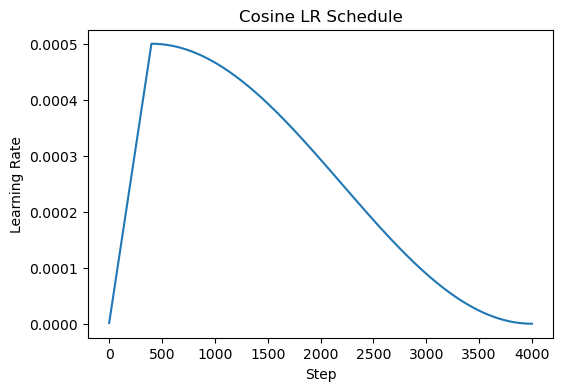

In [26]:
# lr 곡선 확인
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=400, max_lr=5e-4)
lrs = [test_schedule.step() for _ in range(4000)]

plt.figure(figsize=(6,4))
plt.plot(lrs)
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Cosine LR Schedule")
plt.show()

## 11) DataLoader 생성

In [27]:
BATCH_SIZE = 32
EPOCHS = 10

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

len(train_loader)

3750

## 12) 학습 준비

In [28]:
pre_train_model = build_model_pre_train(config).to(device)

optimizer = optim.Adam(pre_train_model.parameters(), lr=5e-4)
train_steps = len(train_loader) * EPOCHS
warmup_steps = max(100, train_steps // 10)
scheduler = CosineSchedule(
    optimizer=optimizer,
    train_steps=train_steps,
    warmup_steps=warmup_steps,
    max_lr=5e-4
)

history = {
    "total_loss": [],
    "nsp_loss": [],
    "mlm_loss": [],
    "nsp_acc": [],
    "mlm_acc": [],
    "lr": []
}

print("train_steps:", train_steps)
print("warmup_steps:", warmup_steps)

train_steps: 37500
warmup_steps: 3750


## 13) 10 epoch 학습
여기서는 softmax 없이 logits 그대로 loss 계산한다.

In [29]:
best_loss = float("inf")
save_path_last = os.path.join(ART_DIR, "mini_bert_last.pt")
save_path_best = os.path.join(ART_DIR, "mini_bert_best.pt")

for epoch in range(EPOCHS):
    pre_train_model.train()

    total_loss_sum = 0.0
    total_nsp_loss_sum = 0.0
    total_mlm_loss_sum = 0.0
    total_nsp_acc_sum = 0.0
    total_mlm_acc_sum = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch in pbar:
        input_ids, segment_ids, mlm_labels, nsp_labels = batch
        input_ids = input_ids.to(device, non_blocking=True)
        segment_ids = segment_ids.to(device, non_blocking=True)
        mlm_labels = mlm_labels.to(device, non_blocking=True)
        nsp_labels = nsp_labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(input_ids, segment_ids)

        loss_nsp = F.cross_entropy(logits_nsp, nsp_labels)
        loss_mlm = lm_loss(mlm_labels, logits_mlm, pad_id=PAD_ID)
        loss = loss_nsp + loss_mlm

        loss.backward()
        torch.nn.utils.clip_grad_norm_(pre_train_model.parameters(), 1.0)
        optimizer.step()
        current_lr = scheduler.step()

        acc_nsp = nsp_acc(nsp_labels, logits_nsp)
        acc_mlm = lm_acc(mlm_labels, logits_mlm, pad_id=PAD_ID)

        total_loss_sum += loss.item()
        total_nsp_loss_sum += loss_nsp.item()
        total_mlm_loss_sum += loss_mlm.item()
        total_nsp_acc_sum += acc_nsp.item()
        total_mlm_acc_sum += acc_mlm.item()

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "nsp": f"{loss_nsp.item():.4f}",
            "mlm": f"{loss_mlm.item():.4f}",
            "lr": f"{current_lr:.6f}"
        })

    epoch_total_loss = total_loss_sum / len(train_loader)
    epoch_nsp_loss = total_nsp_loss_sum / len(train_loader)
    epoch_mlm_loss = total_mlm_loss_sum / len(train_loader)
    epoch_nsp_acc = total_nsp_acc_sum / len(train_loader)
    epoch_mlm_acc = total_mlm_acc_sum / len(train_loader)

    history["total_loss"].append(epoch_total_loss)
    history["nsp_loss"].append(epoch_nsp_loss)
    history["mlm_loss"].append(epoch_mlm_loss)
    history["nsp_acc"].append(epoch_nsp_acc)
    history["mlm_acc"].append(epoch_mlm_acc)
    history["lr"].append(current_lr)

    print(
        f"[Epoch {epoch+1:02d}/{EPOCHS}] "
        f"total_loss={epoch_total_loss:.4f} | "
        f"nsp_loss={epoch_nsp_loss:.4f} | "
        f"mlm_loss={epoch_mlm_loss:.4f} | "
        f"nsp_acc={epoch_nsp_acc:.4f} | "
        f"mlm_acc={epoch_mlm_acc:.4f}"
    )

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": pre_train_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": dict(config),
        "history": history,
    }, save_path_last)

    if epoch_total_loss < best_loss:
        best_loss = epoch_total_loss
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": pre_train_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "config": dict(config),
            "history": history,
        }, save_path_best)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("last model saved to:", save_path_last)
print("best model saved to:", save_path_best)

Epoch 1/10:   0%|          | 0/3750 [00:00<?, ?it/s]

[Epoch 01/10] total_loss=146.9398 | nsp_loss=0.6902 | mlm_loss=146.2496 | nsp_acc=0.5213 | mlm_acc=0.0650


Epoch 2/10:   0%|          | 0/3750 [00:00<?, ?it/s]

[Epoch 02/10] total_loss=125.4753 | nsp_loss=0.6423 | mlm_loss=124.8330 | nsp_acc=0.6247 | mlm_acc=0.1371


Epoch 3/10:   0%|          | 0/3750 [00:00<?, ?it/s]

...

[Epoch 08/10] total_loss=80.4116 | nsp_loss=0.4794 | mlm_loss=79.9321 | nsp_acc=0.7685 | mlm_acc=0.2952


Epoch 9/10:   0%|          | 0/3750 [00:00<?, ?it/s]

[Epoch 09/10] total_loss=79.5785 | nsp_loss=0.4701 | mlm_loss=79.1084 | nsp_acc=0.7746 | mlm_acc=0.2991


Epoch 10/10:   0%|          | 0/3750 [00:00<?, ?it/s]

[Epoch 10/10] total_loss=79.1542 | nsp_loss=0.4670 | mlm_loss=78.6872 | nsp_acc=0.7777 | mlm_acc=0.3015
last model saved to: /home/jovyan/work/mini_bert_project/artifacts/mini_bert_last.pt
best model saved to: /home/jovyan/work/mini_bert_project/artifacts/mini_bert_best.pt


## 14) 결과 시각화

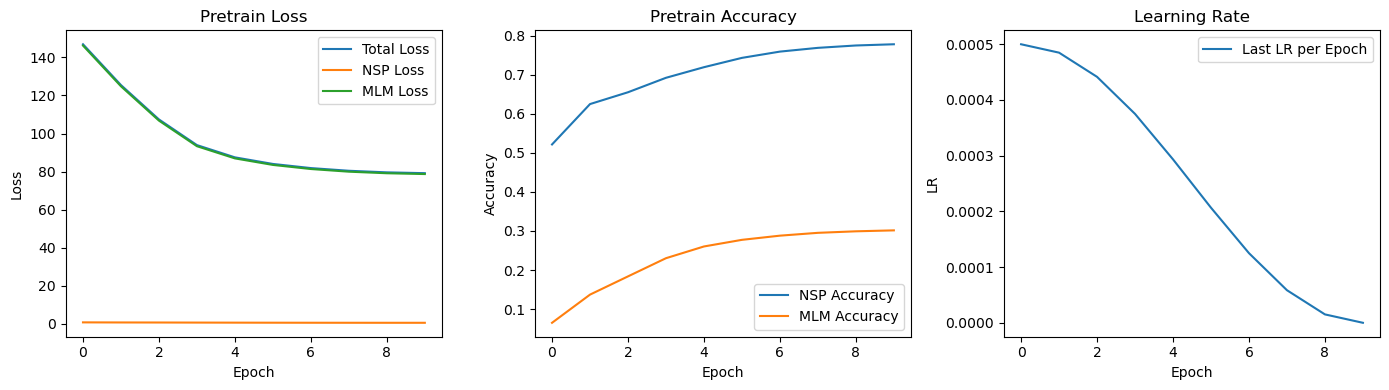

In [30]:
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.plot(history["total_loss"], label="Total Loss")
plt.plot(history["nsp_loss"], label="NSP Loss")
plt.plot(history["mlm_loss"], label="MLM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Pretrain Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(history["nsp_acc"], label="NSP Accuracy")
plt.plot(history["mlm_acc"], label="MLM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Pretrain Accuracy")
plt.legend()

plt.subplot(1,3,3)
plt.plot(history["lr"], label="Last LR per Epoch")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate")
plt.legend()

plt.tight_layout()
plt.show()

## 15) 학습 이력 저장

In [31]:
history_path = os.path.join(ART_DIR, "mini_bert_history.json")
with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history, f, ensure_ascii=False, indent=2)

print("history saved:", history_path)

history saved: /home/jovyan/work/mini_bert_project/artifacts/mini_bert_history.json


## 16) 제출용으로 한 번에 정리하는 셀

In [32]:
print("===== 제출용 체크 =====")
print("vocab size:", vocab.get_piece_size())
print("max seq len:", config.n_seq)
print("params:", f"{sum(p.numel() for p in pre_train_model.parameters()):,}")
print("dataset samples:", len(train_dataset))
print("best model:", save_path_best)
print("last model:", save_path_last)
print("history json:", history_path)
print("dataset meta:", meta_json_path)
print("jsonl dataset:", jsonl_path)

===== 제출용 체크 =====
vocab size: 8000
max seq len: 128
params: 1,013,858
dataset samples: 120000
best model: /home/jovyan/work/mini_bert_project/artifacts/mini_bert_best.pt
last model: /home/jovyan/work/mini_bert_project/artifacts/mini_bert_last.pt
history json: /home/jovyan/work/mini_bert_project/artifacts/mini_bert_history.json
dataset meta: /home/jovyan/work/mini_bert_project/data/mini_bert_pretrain_meta.json
jsonl dataset: /home/jovyan/work/mini_bert_project/data/mini_bert_pretrain.jsonl


## 17) 정리

본 프로젝트에서는 SentencePiece 기반 8000 vocab 토크나이저를 학습하고, BERT pretraining용 MLM/NSP 데이터를 생성하였다. 
MLM은 전체 토큰의 15%를 대상으로 적용하였으며, 선택된 토큰 중 80%는 [MASK], 10%는 random token, 10%는 원래 토큰을 유지하였다.
NSP는 두 문장이 실제로 이어지는 경우와 임의 문장 쌍을 50:50 비율로 구성하였다.
대용량 데이터 처리 시 메모리 초과를 방지하기 위해 데이터셋은 jsonl과 np.memmap 형식으로 저장하였다.

모델은 mini BERT 구조로 설계하였고, vocab size=8000, max sequence length=128, d_model=96, n_head=4, d_head=24, d_ff=384, n_layer=2로 설정하여 전체 파라미터 수를 약 1M 수준으로 맞추었다.
학습은 Adam optimizer와 warmup + cosine decay learning rate scheduler를 사용하여 10 epoch 수행하였다.
학습 과정에서 NSP loss와 MLM loss, NSP accuracy와 MLM accuracy를 함께 기록하고 시각화하였다.